# 3. Machine learning for classification

## Churn prediction project

data: https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv

## Data preparation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
!wget $data -O data-week-3.csv

--2026-09-03 19:15:28--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.


HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘data-week-3.csv’

data-week-3.csv     100%[===================>] 954.59K  --.-KB/s    in 0.02s   

2026-09-03 19:15:29 (38.1 MB/s) - ‘data-week-3.csv’ saved [977501/977501]



In [4]:
df=pd.read_csv('data-week-3.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_cols=list(df.dtypes[df.dtypes=='str'].index)
for c in categorical_cols:
    df[c]=df[c].str.lower().str.replace(' ','_')

In [6]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [7]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [8]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')

In [9]:
df.totalcharges=df.totalcharges.fillna(0)

In [10]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,0.0
753,3115-czmzd,0.0
936,5709-lvoeq,0.0
1082,4367-nuyao,0.0
1340,1371-dwpaz,0.0
3331,7644-omvmy,0.0
3826,3213-vvolg,0.0
4380,2520-sgtta,0.0
5218,2923-arzlg,0.0
6670,4075-wkniu,0.0


In [11]:
df.churn.head()

0     no
1     no
2    yes
3     no
4    yes
Name: churn, dtype: str

In [12]:
df.churn = (df.churn =='yes').astype(int)

## Setting up the validation framework

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
df_full_train,df_test=train_test_split(df, test_size=0.2, random_state=1)

In [15]:
len(df_full_train), len(df_test)

(5634, 1409)

In [16]:
df_train, df_val= train_test_split(df_full_train,test_size=0.25, random_state=1)

In [17]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [18]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)


In [19]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [20]:
del df_train['churn']
del df_val['churn']
del df_test['churn']


## EDA

check missing values

look at the target variable

look at numerical and categorical variables


In [21]:
df_full_train = df_full_train.reset_index(drop=True)

In [22]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [23]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

### churn rate:  0.269968

In [24]:
df_full_train.churn.mean() # in this case is the same as the mean because there are 1s and 0s

np.float64(0.26996805111821087)

In [25]:
global_churn_rate=df_full_train.churn.mean()
round(global_churn_rate, 2)

np.float64(0.27)

In [26]:
df_full_train.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [27]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [28]:
categorical = list(df_full_train.dtypes[df_full_train.dtypes == 'str'].index) +['seniorcitizen']
categorical.pop(0)
categorical

['gender',
 'partner',
 'dependents',
 'phoneservice',
 'multiplelines',
 'internetservice',
 'onlinesecurity',
 'onlinebackup',
 'deviceprotection',
 'techsupport',
 'streamingtv',
 'streamingmovies',
 'contract',
 'paperlessbilling',
 'paymentmethod',
 'seniorcitizen']

In [29]:
df_full_train[categorical].nunique()

gender              2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
seniorcitizen       2
dtype: int64

## Feature importance: churn rate and risk ratio


Churn rate

In [30]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [31]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_female

np.float64(0.27682403433476394)

In [32]:
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
churn_male

np.float64(0.2632135306553911)

In [33]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.26996805111821087)

In [34]:
df_full_train.partner.value_counts()

partner
no     2932
yes    2702
Name: count, dtype: int64

In [35]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_partner

np.float64(0.20503330866025166)

In [36]:
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [37]:
global_churn - churn_no_partner

np.float64(-0.05984095297455855)

In [38]:
global_churn - churn_partner 

np.float64(0.06493474245795922)

In [39]:
global_churn - churn_female

np.float64(-0.006855983216553063)

In [40]:
global_churn - churn_male

np.float64(0.006754520462819769)

Risk ratio

In [41]:
churn_no_partner/global_churn

np.float64(1.2216593879412643)

In [42]:
churn_partner/global_churn

np.float64(0.7594724924338315)

### **Feature importance - difference**

**Differences:**
global - group: 
- '<0': more likely to churn
- '>0': less likely to churn

**remember: if the difference is made group - global the condition are inversed**

This COULD mean that the partner variable is more important to churn prediction than gender


**Risk ratio:**

risk = group/global:
- '<1': less likely to churn
- '>1': more likely to churn

```sql
select gender, avg(churn), avg(churn)-global_churn as diff, avg(churn)/global_churn as risk
from data group by gender
```

Translate this to Pandas:

In [43]:
from IPython.display import display

In [44]:
for c in categorical:
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean']-global_churn
    df_group['risk'] = df_group['mean']/global_churn
    display(df_group)
    print()

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


,mean,count,diff,risk
partner,,,,
no,0.329809,2932,0.059841,1.221659
yes,0.205033,2702,-0.064935,0.759472


,mean,count,diff,risk
dependents,,,,
no,0.313760,3968,0.043792,1.162212
yes,0.165666,1666,-0.104302,0.613651


,mean,count,diff,risk
phoneservice,,,,
no,0.241316,547,-0.028652,0.893870
yes,0.273049,5087,0.003081,1.011412


,mean,count,diff,risk
multiplelines,,,,
no,0.257407,2700,-0.012561,0.953474
no_phone_service,0.241316,547,-0.028652,0.893870
yes,0.290742,2387,0.020773,1.076948


,mean,count,diff,risk
internetservice,,,,
dsl,0.192347,1934,-0.077621,0.712482
fiber_optic,0.425171,2479,0.155203,1.574895
no,0.077805,1221,-0.192163,0.288201


,mean,count,diff,risk
onlinesecurity,,,,
no,0.420921,2801,0.150953,1.559152
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.153226,1612,-0.116742,0.567570


,mean,count,diff,risk
onlinebackup,,,,
no,0.404323,2498,0.134355,1.497672
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.217232,1915,-0.052736,0.804660


,mean,count,diff,risk
deviceprotection,,,,
no,0.395875,2473,0.125907,1.466379
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.230412,1940,-0.039556,0.853480


,mean,count,diff,risk
techsupport,,,,
no,0.418914,2781,0.148946,1.551717
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.159926,1632,-0.110042,0.592390


,mean,count,diff,risk
streamingtv,,,,
no,0.342832,2246,0.072864,1.269897
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.302723,2167,0.032755,1.121328


,mean,count,diff,risk
streamingmovies,,,,
no,0.338906,2213,0.068938,1.255358
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.307273,2200,0.037305,1.138182


,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208


## Feature importance: Mutual information

mutual information -concept from information theory, it tells us how much we can learn about one variable if we know the value of another

In [45]:
from sklearn.metrics import mutual_info_score

In [46]:
mutual_info_score(df_full_train.contract, df_full_train.churn)

0.0983203874041556

In [47]:
mutual_info_score(df_full_train.gender, df_full_train.churn)

0.0001174846211139946

In [48]:
mutual_info_score(df_full_train.partner, df_full_train.churn)

0.009967689095399745

In [49]:
mutual_info_score(df_full_train.onlinesecurity, df_full_train.churn)

0.06308524972985574

In [50]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [51]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

### Feature importance: Correlation

How about numerical columns?

The sign tells us if both of variables are inversely proportional or not

- 0.0 - 0.2 -> low correlation = rarely
- 0.2 - 0.5 -> moderate = sometimes
- 0.6 - 1.0-> strong = often/always


For example seeing tenure and churn:
- tenure: 0-72
- churn {0,1}

- positive correlation: more tenure -> high churn
- negative correlation: less tenure -> low churn
- zero: no effect on churn

In [52]:
df_full_train.tenure.max()

np.int64(72)

In [53]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [54]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.5953420669577875)

In [55]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean() 

np.float64(0.3994413407821229)

In [56]:
df_full_train[df_full_train.tenure > 12].churn.mean() 

np.float64(0.17634908339788277)

In [57]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [58]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18340943683409436)

In [59]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.32499341585462205)

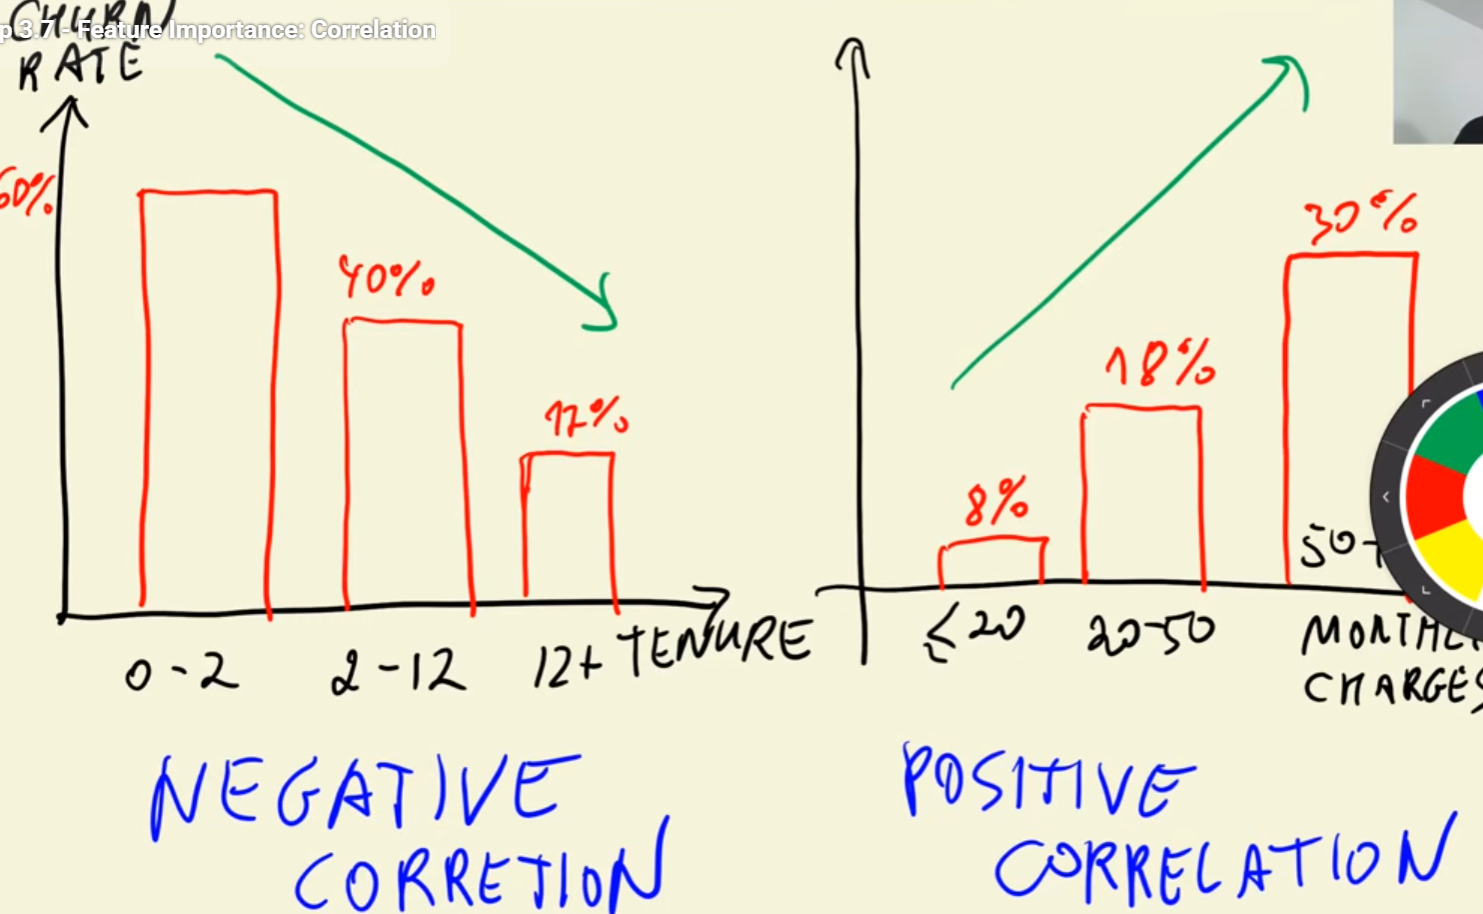

## One-hot encoding

- Use scikit-learn to encode categorical features

In [60]:
from sklearn.feature_extraction import DictVectorizer

In [61]:
train_dicts = df_train[categorical+numerical].to_dict(orient='records')

In [62]:
dv = DictVectorizer(sparse=False)

In [63]:
dv.fit(train_dicts)

DictVectorizer(sparse=False)

In [64]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [65]:
list(dv.transform(train_dicts[:5])[0])

[np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(115.5),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(72.0),
 np.float64(8425.15)]

**if a numerical variable is inserted in the one hot encoding the system detects it and just signalized it**

In [66]:
X_train = dv.fit_transform(train_dicts) #fit_transforms function works as fit and transform at the same time

In [67]:
X_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.20000e+01, 8.42515e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+01, 1.02155e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.00000e+00, 4.13650e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        2.00000e+00, 1.90050e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        2.70000e+01, 7.61950e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        9.00000e+00, 7.51650e+02]], shape=(4225, 45))

In [68]:
val_dicts = df_val[categorical+numerical].to_dict(orient='records')

In [69]:
X_val=dv.fit_transform(val_dicts)

## Logistic Regression

In [70]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [71]:
z = np.linspace(-7, 7, 51)

In [72]:
sigmoid(z)

array([9.11051194e-04, 1.20508423e-03, 1.59386223e-03, 2.10780106e-03,
       2.78699622e-03, 3.68423990e-03, 4.86893124e-03, 6.43210847e-03,
       8.49286285e-03, 1.12064063e-02, 1.47740317e-02, 1.94550846e-02,
       2.55807883e-02, 3.35692233e-02, 4.39398154e-02, 5.73241759e-02,
       7.44679452e-02, 9.62155417e-02, 1.23467048e-01, 1.57095469e-01,
       1.97816111e-01, 2.46011284e-01, 3.01534784e-01, 3.63547460e-01,
       4.30453776e-01, 5.00000000e-01, 5.69546224e-01, 6.36452540e-01,
       6.98465216e-01, 7.53988716e-01, 8.02183889e-01, 8.42904531e-01,
       8.76532952e-01, 9.03784458e-01, 9.25532055e-01, 9.42675824e-01,
       9.56060185e-01, 9.66430777e-01, 9.74419212e-01, 9.80544915e-01,
       9.85225968e-01, 9.88793594e-01, 9.91507137e-01, 9.93567892e-01,
       9.95131069e-01, 9.96315760e-01, 9.97213004e-01, 9.97892199e-01,
       9.98406138e-01, 9.98794916e-01, 9.99088949e-01])

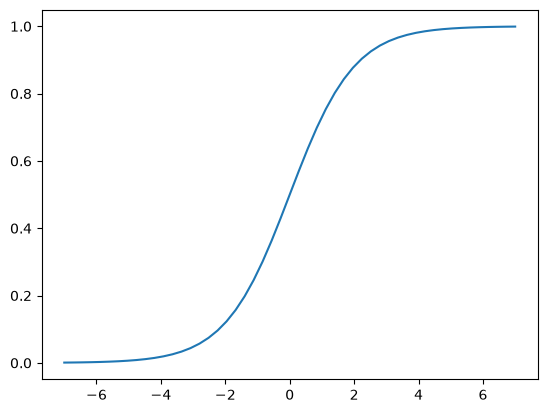

In [73]:
plt.plot(z,sigmoid(z))

In [74]:
def linear_regression(xi):
    result = w0
    for j in range(len(w)):
        result = result+xi[j]*w[j]
    return result

def LogisticRegression(X):
    score = w0
    for j in range(len(w)):
        score = score+xi[j]*w[j]
    result = sigmoid(score)
    return result
    

## Training logistic regression with Scikit-learn

- Train a model with scikit-learn
- Apply it to the validation dataset
- Calculate the accuracy

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
model = LogisticRegression()
model.fit(X_train, y_train)

/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [77]:
model.coef_[0].round(3)

array([ 0.564, -0.154, -0.519, -0.013, -0.095,  0.071, -0.098, -0.082,
       -0.033, -0.076, -0.354,  0.343, -0.098,  0.002, -0.251,  0.162,
       -0.02 ,  0.066, -0.098, -0.076,  0.251, -0.098, -0.261, -0.228,
        0.119, -0.121,  0.012, -0.095, -0.03 ,  0.045, -0.028,  0.162,
       -0.271,  0.221, -0.097, -0.098,  0.087, -0.05 , -0.098,  0.039,
        0.194, -0.098, -0.205, -0.072,  0.   ])

In [78]:
model.intercept_[0]

np.float64(-0.1109287445794238)

In [79]:
model.predict(X_train)  # Hard predictions - because these results are churn 1 or 0 - yes or no

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

In [80]:
y_pred = model.predict_proba(X_val)[:,1] #soft predictions - because these results are probabilities that have to go through a threshold function to get a 1 or 0.

In [81]:
y_pred

array([0.00786347, 0.20992803, 0.2237105 , ..., 0.15014869, 0.77668113,
       0.81035774], shape=(1409,))

In [82]:
churn_decision = (y_pred >=0.5) #threshold function yes if probability >=0.5

In [83]:
df_val[churn_decision].customerid

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 322, dtype: str

In [84]:
(y_val == churn_decision).mean()

np.float64(0.801277501774308)

In [85]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [86]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction']=churn_decision.astype(int)
df_pred['actual']=y_val

In [87]:
df_pred['correct'] = df_pred.prediction==df_pred.actual

In [88]:
df_pred.correct.mean()

np.float64(0.801277501774308)

## Model Interpretation

- look at coeficients
- traina smaller model with fewer features

In [89]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [90]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.564),
 'contract=one_year': np.float64(-0.154),
 'contract=two_year': np.float64(-0.519),
 'dependents=no': np.float64(-0.013),
 'dependents=yes': np.float64(-0.095),
 'deviceprotection=no': np.float64(0.071),
 'deviceprotection=no_internet_service': np.float64(-0.098),
 'deviceprotection=yes': np.float64(-0.082),
 'gender=female': np.float64(-0.033),
 'gender=male': np.float64(-0.076),
 'internetservice=dsl': np.float64(-0.354),
 'internetservice=fiber_optic': np.float64(0.343),
 'internetservice=no': np.float64(-0.098),
 'monthlycharges': np.float64(0.002),
 'multiplelines=no': np.float64(-0.251),
 'multiplelines=no_phone_service': np.float64(0.162),
 'multiplelines=yes': np.float64(-0.02),
 'onlinebackup=no': np.float64(0.066),
 'onlinebackup=no_internet_service': np.float64(-0.098),
 'onlinebackup=yes': np.float64(-0.076),
 'onlinesecurity=no': np.float64(0.251),
 'onlinesecurity=no_internet_service': np.float64(-0.098),
 'onlinesecurity=yes

In [91]:
small = ['contract', 'tenure', 'monthlycharges']

In [92]:
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [93]:
dicts_train_small = df_train[small].iloc[:10].to_dict(orient='records')
dicts_vall_small = df_val[small].to_dict(orient='records')

In [94]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

DictVectorizer(sparse=False)

In [95]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=two_year', 'monthlycharges',
       'tenure'], dtype=object)

In [96]:
X_train_small = dv_small.transform(dicts_train_small)

In [97]:
model_small = LogisticRegression()
model_small.fit(X_train_small, y_train[:10])

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [98]:
w0=model_small.intercept_[0]

In [99]:
w = model_small.coef_[0]
w

array([ 2.21436903e-04, -2.19287740e-04,  6.48078731e-02, -3.17537188e-01])

In [100]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=month-to-month': np.float64(0.0),
 'contract=two_year': np.float64(-0.0),
 'monthlycharges': np.float64(0.065),
 'tenure': np.float64(-0.318)}

## Using the model

In [101]:
dicts_full_train = df_full_train[categorical+numerical].to_dict(orient='records')

In [102]:
dv=DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

In [103]:
y_full_train=df_full_train.churn.values

In [104]:
model = LogisticRegression()
model.fit(X_full_train, y_full_train)

/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [105]:
dicts_test = df_test[categorical+numerical].to_dict(orient='records')

In [106]:
X_test = dv.transform(dicts_test)

In [107]:
y_pred = model.predict_proba(X_test)[:,1]

In [108]:
churn_decision=(y_pred >=0.5)

In [109]:
(churn_decision==y_test).mean()

np.float64(0.8140525195173882)

In [110]:
customer = dicts_test[10]
customer

{'gender': 'male',
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'no',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'no',
 'onlinebackup': 'yes',
 'deviceprotection': 'no',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'mailed_check',
 'seniorcitizen': 1,
 'tenure': 32,
 'monthlycharges': 93.95,
 'totalcharges': 2861.45}

In [111]:
X_customer = dv.transform([customer])
X_customer.shape

(1, 45)

In [112]:
model.predict_proba(X_customer)[0,1]

np.float64(0.4979219389473276)

In [113]:
y_test[10]

np.int64(0)

# 4. Evaluation Metrics

## Accuracy and Dummy Model

- % correct predictions or How many of my predictions were correct?

In [114]:
len(y_val)

1409

In [116]:
(y_val==churn_decision).sum()

np.int64(869)

In [117]:
(y_val==churn_decision).sum()/len(y_val)

np.float64(0.6167494677075941)

In [119]:
thresholds = np.linspace(0,1,21)
scores=[]

for t in thresholds:
    churn_decision=(y_pred >=t)
    score = (y_val==churn_decision).mean()
    scores.append(score)
scores

[np.float64(0.2739531582682754),
 np.float64(0.4038325053229241),
 np.float64(0.45067423704755144),
 np.float64(0.47977288857345635),
 np.float64(0.5046132008516678),
 np.float64(0.5330021291696239),
 np.float64(0.5372604684173172),
 np.float64(0.559971611071682),
 np.float64(0.5748757984386089),
 np.float64(0.5876508161816891),
 np.float64(0.6167494677075941),
 np.float64(0.6266855926188787),
 np.float64(0.6472675656493967),
 np.float64(0.673527324343506),
 np.float64(0.6912704045422285),
 np.float64(0.7097232079489),
 np.float64(0.7196593328601846),
 np.float64(0.7260468417317246),
 np.float64(0.7260468417317246),
 np.float64(0.7260468417317246),
 np.float64(0.7260468417317246)]

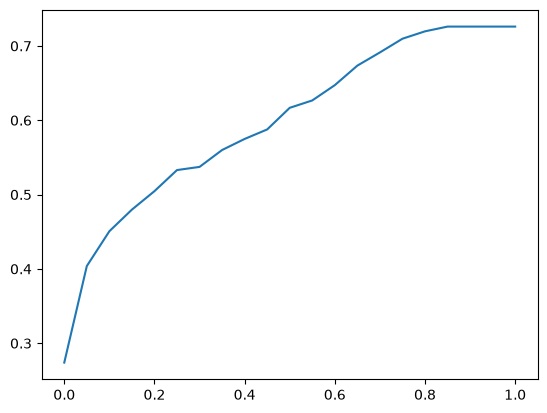

In [120]:
plt.plot(thresholds, scores)

In [121]:
#Scikit-learn's accuracy function
from sklearn.metrics import accuracy_score

In [148]:
accuracy_score(y_test, y_pred >=0.5)

0.8140525195173882

In [149]:
thresholds = np.linspace(0,1,21)
scores=[]

for t in thresholds:
    churn_decision=(y_pred >=t)
    score = accuracy_score(y_test, y_pred>=t)
    print(t,':', score)
    scores.append(score)

0.0 : 0.24698367636621718
0.05 : 0.48616039744499645
0.1 : 0.6011355571327183
0.15000000000000002 : 0.6728176011355571
0.2 : 0.709013484740951
0.25 : 0.7416607523066004
0.30000000000000004 : 0.7643718949609652
0.35000000000000003 : 0.7814052519517388
0.4 : 0.7877927608232789
0.45 : 0.7991483321504613
0.5 : 0.8140525195173882
0.55 : 0.815471965933286
0.6000000000000001 : 0.8147622427253371
0.65 : 0.8069552874378992
0.7000000000000001 : 0.794889992902768
0.75 : 0.7764371894960965
0.8 : 0.7622427253371186
0.8500000000000001 : 0.7530163236337828
0.9 : 0.7530163236337828
0.9500000000000001 : 0.7530163236337828
1.0 : 0.7530163236337828


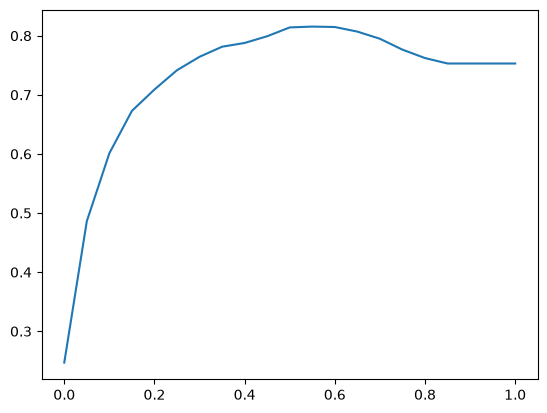

In [150]:
plt.plot(thresholds, scores)

## Confusion Matrix

- Different types of errors and correct decisions
- Arranging them in a table

**What type of predictions your classification model got right and wrong**

In [143]:
actual_positive = (y_test==1)
actual_negative = (y_test==0)

In [155]:
t = 0.5
predict_positive = (y_pred>=t)
predict_negative = (y_pred<t)

In [156]:
predict_positive & actual_positive

array([False, False, False, ..., False, False,  True], shape=(1409,))

In [157]:
tp = (predict_positive & actual_positive).sum() 
tn = (predict_negative & actual_negative).sum() 
fp = (predict_positive & actual_negative).sum() 
fn = (predict_negative & actual_positive).sum() 

In [159]:
confusion_matrix = np.array([
    [tn, fp],
    [fn,tp]
])
confusion_matrix

array([[943, 118],
       [144, 204]])

In [161]:
(confusion_matrix/confusion_matrix.sum()).round(2)

array([[0.67, 0.08],
       [0.1 , 0.14]])

In [173]:
df_y_test = pd.DataFrame(y_test)
df_y_test.value_counts()

0
0    1061
1     348
Name: count, dtype: int64

## Precision and recall

In [174]:
precision = tp/(tp+fp)
precision

np.float64(0.6335403726708074)

In [175]:
recall = tp/(tp+ fn)
recall

np.float64(0.5862068965517241)

## ROC Curves

TPR and FPR

In [176]:
tpr=tp/(tp+fn)
tpr

np.float64(0.5862068965517241)

In [177]:
fpr=fp/(fp+tn)
fpr

np.float64(0.1112158341187559)

In [179]:
scores=[]

thresholds = np.linspace(0,1,101)


for t in thresholds:
    actual_positive=(y_test==1)
    actual_negative=(y_test==0)
    predict_positive=(y_pred>=t)
    predict_negative=(y_pred<t)

    tp=(predict_positive&actual_positive).sum()
    tn=(predict_negative & actual_negative).sum()
    fp=(predict_positive&actual_negative).sum()
    fn=(predict_negative&actual_positive).sum()

    scores.append((t,tp,tn,fp,fn))

In [181]:
columns = ['thresholds', 'tp','tn','fp','fn']
df_scores=pd.DataFrame(scores, columns=columns)
df_scores

,thresholds,tp,tn,fp,fn
0,0.00,348,0,1061,0
1,0.01,347,121,940,1
2,0.02,344,206,855,4
3,0.03,344,257,804,4
4,0.04,344,298,763,4
...,...,...,...,...,...
96,0.96,0,1061,0,348
97,0.97,0,1061,0,348
98,0.98,0,1061,0,348
99,0.99,0,1061,0,348


In [182]:
df_scores['tpr']=df_scores.tp/(df_scores.tp+df_scores.fn)
df_scores['fpr']=df_scores.fp/(df_scores.fp+df_scores.tn)


In [183]:
df_scores

,thresholds,tp,tn,fp,fn,tpr,fpr
0,0.00,348,0,1061,0,1.000000,1.000000
1,0.01,347,121,940,1,0.997126,0.885957
2,0.02,344,206,855,4,0.988506,0.805844
3,0.03,344,257,804,4,0.988506,0.757776
4,0.04,344,298,763,4,0.988506,0.719133
...,...,...,...,...,...,...,...
96,0.96,0,1061,0,348,0.000000,0.000000
97,0.97,0,1061,0,348,0.000000,0.000000
98,0.98,0,1061,0,348,0.000000,0.000000
99,0.99,0,1061,0,348,0.000000,0.000000


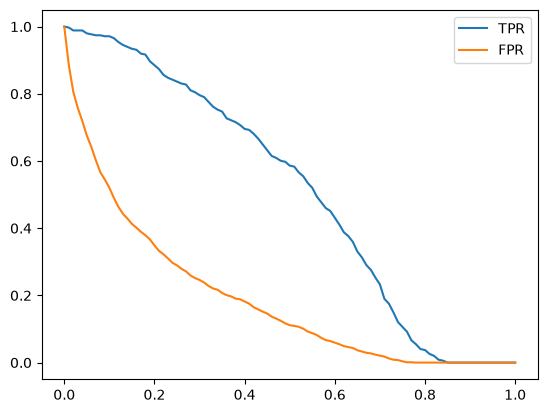

In [185]:
plt.plot(df_scores.thresholds, df_scores['tpr'], label='TPR')
plt.plot(df_scores.thresholds, df_scores['fpr'], label='FPR')
plt.legend()

### Random Model

In [187]:
np.random.seed(1)
y_rand=np.random.uniform(0,1, size=len(y_test))
y_rand

array([4.17022005e-01, 7.20324493e-01, 1.14374817e-04, ...,
       7.73916250e-01, 3.34276405e-01, 8.89982208e-02], shape=(1409,))

In [188]:
((y_rand>=0.5) == y_test).mean()

np.float64(0.49325762952448543)

In [189]:
def tpr_fpr_dataframe(y_test, y_pred):
    scores=[]
    thresholds = np.linspace(0,1,101)

    for t in thresholds:
        actual_positive=(y_test==1)
        actual_negative=(y_test==0)
        predict_positive=(y_pred>=t)
        predict_negative=(y_pred<t)

        tp=(predict_positive&actual_positive).sum()
        tn=(predict_negative & actual_negative).sum()
        fp=(predict_positive&actual_negative).sum()
        fn=(predict_negative&actual_positive).sum()

        scores.append((t,tp,tn,fp,fn))

    columns = ['thresholds', 'tp','tn','fp','fn']
    df_scores=pd.DataFrame(scores, columns=columns)

    df_scores['tpr']=df_scores.tp/(df_scores.tp+df_scores.fn)
    df_scores['fpr']=df_scores.fp/(df_scores.fp+df_scores.tn)

    return df_scores


In [190]:
df_rand=tpr_fpr_dataframe(y_test, y_rand)

In [191]:
df_rand

,thresholds,tp,tn,fp,fn,tpr,fpr
0,0.00,348,0,1061,0,1.000000,1.000000
1,0.01,346,12,1049,2,0.994253,0.988690
2,0.02,336,25,1036,12,0.965517,0.976437
3,0.03,332,39,1022,16,0.954023,0.963242
4,0.04,327,47,1014,21,0.939655,0.955702
...,...,...,...,...,...,...,...
96,0.96,13,1019,42,335,0.037356,0.039585
97,0.97,10,1024,37,338,0.028736,0.034873
98,0.98,5,1039,22,343,0.014368,0.020735
99,0.99,1,1049,12,347,0.002874,0.011310


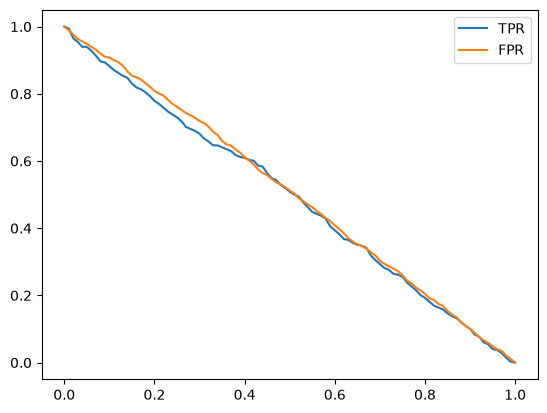

In [192]:
plt.plot(df_rand.thresholds, df_rand['tpr'], label='TPR')
plt.plot(df_rand.thresholds, df_rand['fpr'], label='FPR')
plt.legend()

### Ideal model

In [205]:
num_neg=(y_test==0).sum()
num_pos=(y_test==1).sum()
num_neg,num_pos

(np.int64(1061), np.int64(348))

In [194]:
y_ideal = np.repeat([0,1], [num_neg, num_pos])
y_ideal

array([0, 0, 0, ..., 1, 1, 1], shape=(1409,))

In [196]:
y_ideal_pred = np.linspace(0,1,len(y_test))
y_ideal_pred

array([0.00000000e+00, 7.10227273e-04, 1.42045455e-03, ...,
       9.98579545e-01, 9.99289773e-01, 1.00000000e+00], shape=(1409,))

In [206]:
1-y_test.mean()

np.float64(0.7530163236337828)

In [207]:
((y_ideal_pred >= 0.753) == y_ideal).mean()

np.float64(1.0)

In [211]:
ideal_df = tpr_fpr_dataframe(y_ideal,y_ideal_pred)
ideal_df

,thresholds,tp,tn,fp,fn,tpr,fpr
0,0.00,348,0,1061,0,1.000000,1.000000
1,0.01,348,15,1046,0,1.000000,0.985862
2,0.02,348,29,1032,0,1.000000,0.972667
3,0.03,348,43,1018,0,1.000000,0.959472
4,0.04,348,57,1004,0,1.000000,0.946277
...,...,...,...,...,...,...,...
96,0.96,57,1061,0,291,0.163793,0.000000
97,0.97,43,1061,0,305,0.123563,0.000000
98,0.98,29,1061,0,319,0.083333,0.000000
99,0.99,15,1061,0,333,0.043103,0.000000


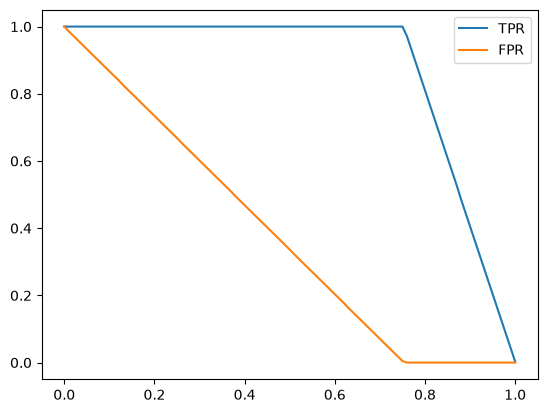

In [212]:
plt.plot(ideal_df.thresholds, ideal_df['tpr'], label='TPR')
plt.plot(ideal_df.thresholds, ideal_df['fpr'], label='FPR')
plt.legend()

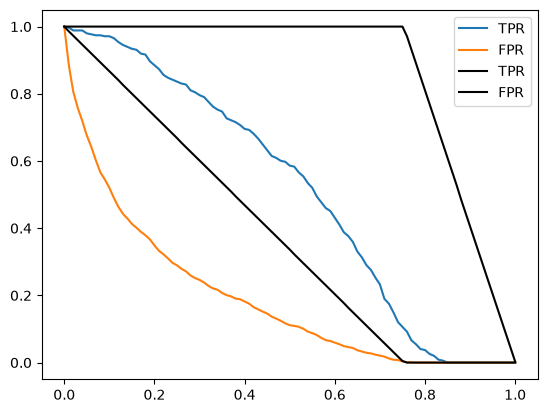

In [215]:
plt.plot(df_scores.thresholds, df_scores['tpr'], label='TPR')
plt.plot(df_scores.thresholds, df_scores['fpr'], label='FPR')
plt.plot(ideal_df.thresholds, ideal_df['tpr'], label='TPR', color='black')
plt.plot(ideal_df.thresholds, ideal_df['fpr'], label='FPR', color='black')
plt.legend()

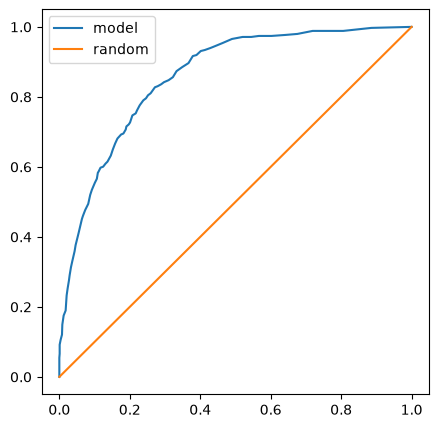

In [221]:
plt.figure(figsize=(5,5))
plt.plot(df_scores.fpr, df_scores.tpr, label='model')
plt.plot([0,1], [0,1],label='random')
# plt.plot(ideal_df.fpr, ideal_df.tpr, label='ideal')
plt.legend()

In [222]:
from sklearn.metrics import roc_curve

In [223]:
fpr, tpr, thresholds=roc_curve(y_test, y_pred)

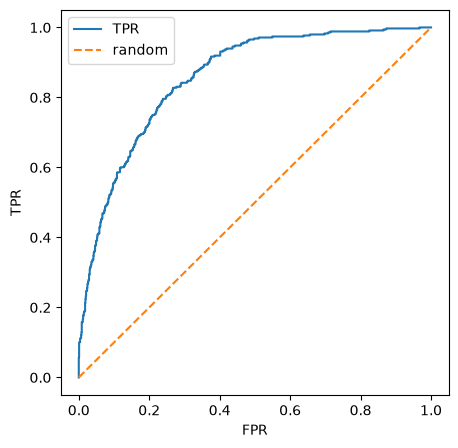

In [224]:
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label='TPR')
plt.plot([0,1], [0,1],label='random', linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

### ROC-AUC

In [225]:
from sklearn.metrics import auc

In [227]:
auc(fpr,tpr)

0.8568079885599142

In [228]:
auc(df_scores.fpr, df_scores.tpr)

0.8571329909974323

In [229]:
auc(ideal_df.fpr, ideal_df.tpr)

0.9999322911588503

In [230]:
auc(df_rand.fpr, df_rand.tpr)

0.4871813621935498

In [232]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_pred)

0.8568079885599142

In [233]:
auc(fpr,tpr)

0.8568079885599142

### Cross-validation

- evaluating the same model on different subsets of data
- getting the average prediction and the spread within prediction

In [235]:
from sklearn.linear_model import LogisticRegression

In [ ]:
def train(df,y, C=1.0):
    dicts=df[categorical+numerical].to_dict(orient='records')

    dv=DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv,model

In [268]:
dv, model = train(df_train, y_train, C=0.001)

/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
def predict(df,dv,model):
    dicts = df[categorical+numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:,1]

    return y_pred

In [270]:
y_pred = predict(df_val, dv,model)

In [264]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, shuffle=True, random_state=1)

In [265]:
train_idx, val_idx = next(kfold.split(df_full_train)) #genera un iterable
len(train_idx),len(val_idx)

(5070, 564)

In [250]:
df_train=df_full_train.iloc[train_idx]
df_val=df_full_train.iloc[val_idx]

In [256]:
from tqdm.auto import tqdm

In [274]:
n_splits=5
for c in tqdm([0.001,0.01,0.1,0.5,1,5,10]):

    scores=[]

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train=df_full_train.iloc[train_idx]
        df_val=df_full_train.iloc[val_idx]

        y_train=df_train.churn.values
        y_val=df_val.churn.values

        dv,model=train(df_train, y_train, C=c)
        y_pred = predict(df_val,dv,model)

        score = roc_auc_score(y_val, y_pred)
        scores.append(score)
    print('C=%s %.3f +- %.3f' %(c, np.mean(scores), np.std(scores)))

  0%|          | 0/7 [00:00<?, ?it/s]

/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

C=0.001 0.827 +- 0.014


/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

C=0.01 0.841 +- 0.012


/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

C=0.1 0.841 +- 0.012


/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

C=0.5 0.840 +- 0.013


/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

C=1 0.842 +- 0.013


/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

C=5 0.841 +- 0.012


/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

C=10 0.840 +- 0.013


/workspaces/MLZoomCamp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [267]:
print('%.3f +- %.3f' %(np.mean(scores), np.std(scores)))

0.842 +- 0.013


In [284]:
def train(df,y_train, C=1.0):
    dicts=df[categorical+numerical].to_dict(orient='records')

    dv=DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv,model

def predict(df,dv,model):
    dicts = df[categorical+numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:,1]

    return y_pred

In [285]:
df_full_train.churn.count()

np.int64(5634)

In [286]:
df_full_train.customerid.count()

np.int64(5634)

In [287]:
dv,model=train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test,dv,model)

score = roc_auc_score(y_test, y_pred)
score

0.8584032088573997